(a) - Entropy (bit):
--------------------------------------
n = 1  | Shannon-Entropy: 1.0000 bit
n = 2  | Shannon-Entropy: 1.5000 bit
n = 4  | Shannon-Entropy: 2.0306 bit
n = 8  | Shannon-Entropy: 2.5442 bit




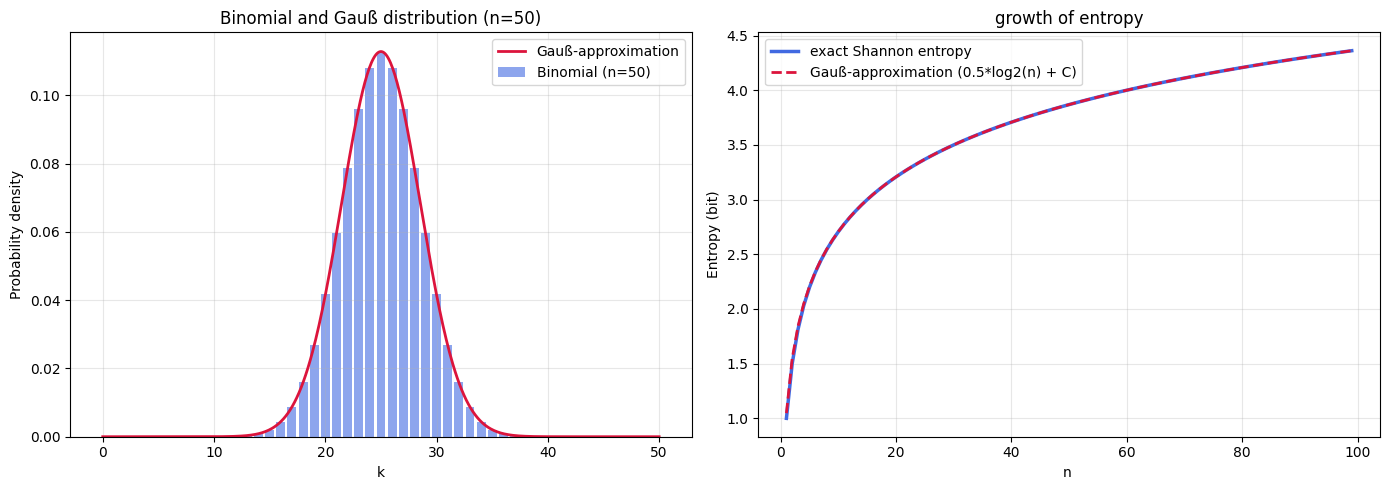

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# --- Teil (a): Exakte Shannon-Entropie berechnen ---
def shannon_entropy_binomial(n, p=0.5):
    k = np.arange(0, n + 1)
    probabilities = binom.pmf(k, n, p)
    return -np.sum(probabilities * np.log2(probabilities))

n_values = [1, 2, 4, 8]
print("(a) - Entropy (bit):")
print("-" * 38)
for n in n_values:
    H = shannon_entropy_binomial(n)
    print(f"n = {n:<2} | Shannon-Entropy: {H:.4f} bit")
print("\n" + "="*50 + "\n")


# --- Teil (b) & (c): Visualisierung der Approximation und des Wachstums ---
n_large = 50  # Beispielhaft für ein größeres n
p = 0.5

# Parameter der Binomialverteilung
k_arr = np.arange(0, n_large + 1)
p_binomial = binom.pmf(k_arr, n_large, p)

# Parameter der Normalverteilung
mu = n_large * p
sigma = np.sqrt(n_large * p * (1 - p))
x_arr = np.linspace(0, n_large, 500)
p_normal = norm.pdf(x_arr, mu, sigma)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(k_arr, p_binomial, alpha=0.6, color='royalblue', label=f'Binomial (n={n_large})')
plt.plot(x_arr, p_normal, color='crimson', lw=2, label='Gauß-approximation')
plt.title(f'Binomial and Gauß distribution (n={n_large})')
plt.xlabel('k')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Plot: Wachstum der Entropie mit n (Teil c)
n_range = np.arange(1, 100)
entropy_exact = [shannon_entropy_binomial(n) for n in n_range]
# Kontinuierliche Approximation: H = 0.5 * log2(2 * pi * e * sigma^2) mit sigma^2 = n/4
entropy_approx = 0.5 * np.log2(2 * np.pi * np.e * (n_range / 4))

plt.subplot(1, 2, 2)
plt.plot(n_range, entropy_exact, label='exact Shannon entropy', color='royalblue', lw=2.5)
plt.plot(n_range, entropy_approx, '--', label='Gauß-approximation (0.5*log2(n) + C)', color='crimson', lw=2)
plt.title('growth of entropy')
plt.xlabel('n ')
plt.ylabel('Entropy (bit)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()